<a href="https://colab.research.google.com/github/blancavazquez/Programa-intensivo-2026-Modulo3/blob/main/notebooks/sesion_lunes/2_Perceptr%C3%B3n_m%C3%BAltiples_salidas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Programa Intensivo en Ciencia de Datos de los Fundamentos al Deep Learning**


## **Módulo 3**: *Redes Neuronales Artificiales*

## **Objetivo de esta Notebook**: Construir ejemplos de Perceptrón simple, Perceptrón multivariable y Perceptrón multivariable con múltiples salidas (capa de neuronas) con sus funciones de activación y visualizando sus fronteras de decisión. Esta libreta está inspirada del material desarrolado por el Ing. Gabriel Carcedo, estudiante del PCIC, IIMAS.


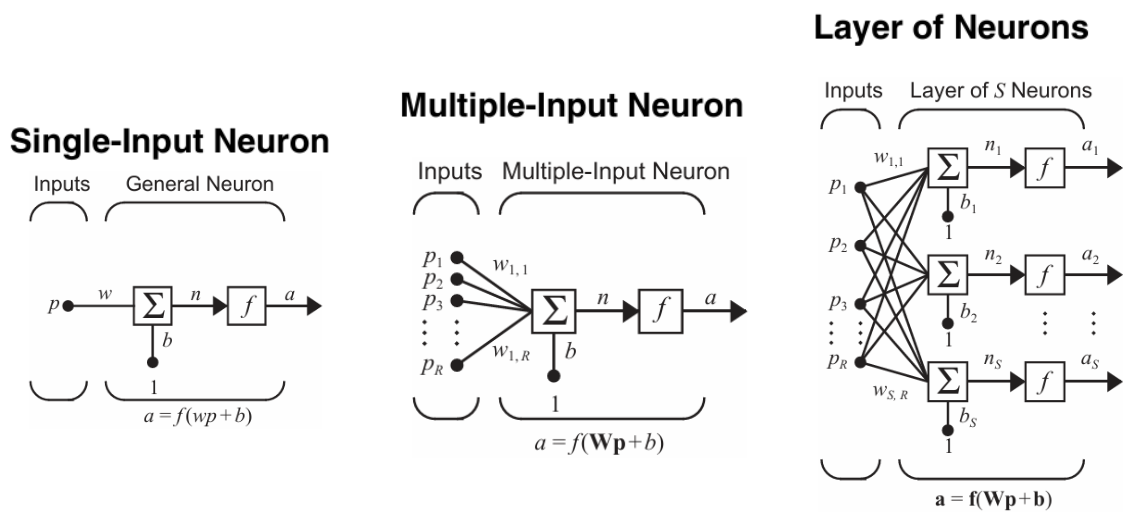

*Recuperado de*: **Hagan M, Demuth H, Beale M, De Jesús O** (2014). *Neural Network Design 2nd Ed*.

# Paquetes y Librerías 📚

In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
def step(n):
    return np.where(n >= 0, 1, 0)

def sigmoid(n):
    return 1 / (1 + np.exp(-n))

def tanh(n):
    return np.tanh(n)

def relu(n):
    return np.maximum(0, n)

---
# **Perceptrón simple con múltiples entradas y múltiples salidas**

## R entradas, S salidas
---

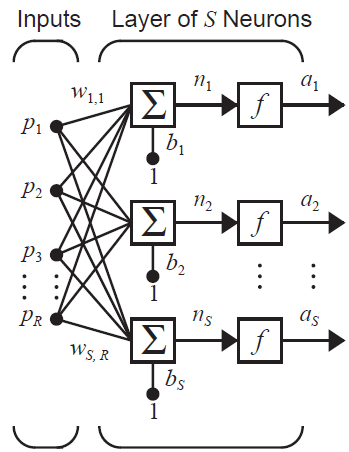

*Recuperado de*: **Hagan M, Demuth H, Beale M, De Jesús O** (2014). *Neural Network Design 2nd Ed*.

# Generar el dataset

In [ ]:
# Número de registros
samples = 1000

np.random.seed(10)  # semilla para reproducibilidad

# Generar promedios aleatorios
promedios = np.random.uniform(5, 10, samples)   # promedios de 5 a 10
calif_examen  = np.random.uniform(5, 10, samples)     # resultados de examen de 50 a 100

# Etiquetas
aceptado = ((promedios > 7.5) & (calif_examen > 7)).astype(int)   # regla: si promedio > 7.5 y examen > 70 → aceptado=1
beca = ((promedios > 8) & (calif_examen > 8)).astype(int)       # regla: si promedio > 8.5 y examen > 80 → beca=1

# Dataset de múltiples entradas y múltiples salidas
p = np.column_stack((promedios, calif_examen))  #  (n, 2)
a = np.column_stack((aceptado, beca))   #  (n, 2)

dataset_df = pd.DataFrame({'Candidato': range(1, samples + 1),
                           'Promedio Bachillerato': np.round(promedios, 2),
                           'Examen conocimientos': np.round(calif_examen, 2),
                           'Dictamen de ingreso': aceptado,
                           'Beca': beca})
dataset_df.set_index('Candidato', inplace=True)
dataset_df

,Promedio Bachillerato,Examen conocimientos,Dictamen de ingreso,Beca
Candidato,,,,
1,8.86,6.74,0,0
2,5.10,9.04,0,0
3,8.17,7.30,1,0
4,8.74,8.13,1,1
5,7.49,6.02,0,0
...,...,...,...,...
996,7.58,9.58,1,0
997,6.05,7.48,0,0
998,5.83,7.28,0,0


# Visualizar el Dataset

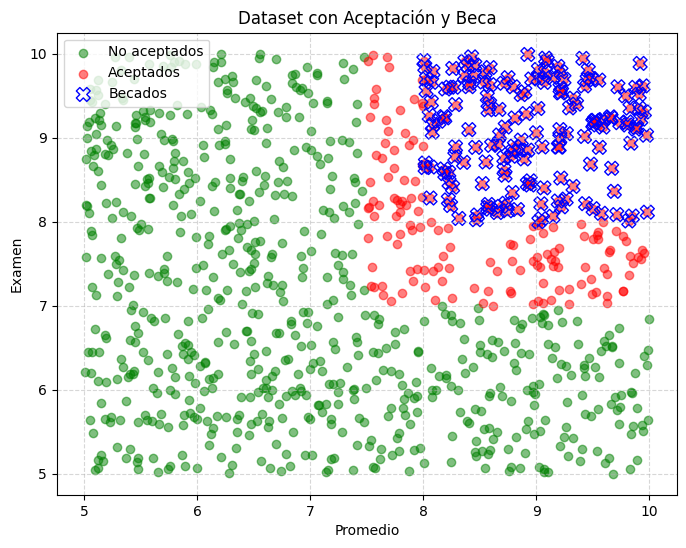

In [ ]:
# Visualización
plt.figure(figsize=(8, 6))
colors = ['r', 'g']

# Aceptados
plt.scatter(promedios[aceptado == 0], calif_examen[aceptado == 0], c=colors[1], label='No aceptados', alpha=0.5)
plt.scatter(promedios[aceptado == 1], calif_examen[aceptado == 1], c=colors[0], label='Aceptados', alpha=0.5)

# Becados
beca_indices = np.where(beca == 1)[0]
plt.scatter(promedios[beca_indices], calif_examen[beca_indices], facecolors='none', edgecolors='b', marker='X', s=100, label='Becados')

plt.legend()

plt.xlabel("Promedio")
plt.ylabel("Examen")
plt.title("Dataset con Aceptación y Beca")
plt.grid(ls='--', alpha=0.5)
plt.show()

# Inicialización de parámetros

In [ ]:
# Matriz de Pesos y VECTOR de Sesgos
np.random.seed(1)
W = np.random.rand(2, 2)  # (2 entradas, 2 salidas)
b = np.random.rand(1, 2)  # (1, 2)
epochs = 500
lr = 0.01

print("Pesos iniciales:", W, W.shape)
print("Bias inicial:", b)

Pesos iniciales: [[4.17022005e-01 7.20324493e-01]
 [1.14374817e-04 3.02332573e-01]] (2, 2)
Bias inicial: [[0.14675589 0.09233859]]


### Notar que los pesos ahora son una matriz (2, 2) y los sesgos (o biases) son un vector (1, 2) ❗

### Función sumatoria

In [ ]:
def SumMult(p, W, b):
    """
    Calcula n = p*W + b
    p : vector de entradas (n, d)  -> cada fila es un ejemplo
    W : vector de pesos (d,)
    b : bias escalar
    """
    return np.dot(p, W) + b # Producto punto

# Entrenamiento

In [ ]:
for epoch in range(epochs):
    for i in range(len(p)):
        pi = p[i].reshape(1, 2) # (1, 2)
        ai = a[i].reshape(1, 2) # (1, 2)

        # Paso hacia adelante
        n = SumMult(pi, W, b) # (1, 2)
        a_hat = step(n) # salida predicha (1, 2)

        # Cálculo del error
        error = ai - a_hat # (1, 2)

        # Actualización de pesos
        W += lr * np.dot(pi.T, error) # (2, 2)
        b += lr * error # (1, 2)

# Ver el Perceptrón 🔎

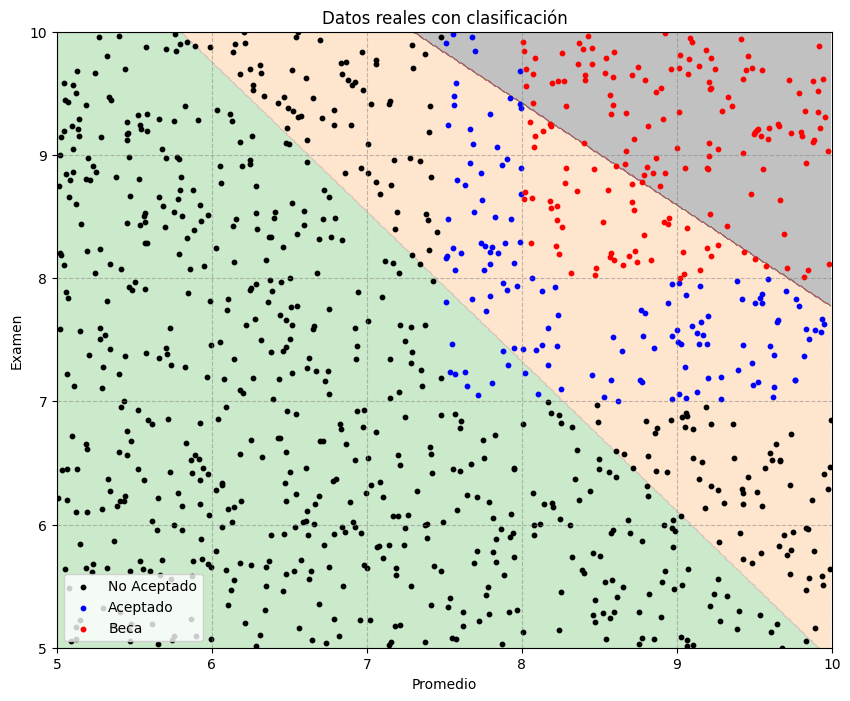

In [ ]:
# Visualización de fronteras
x_min, x_max = 5, 10
y_min, y_max = 5, 10
h = 0.01

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

# Paso por el perceptrón entrenado
n_grid = SumMult(grid, W, b)
a_grid = step(n_grid)   # valores en (0,1)

# Umbralizar
aceptado_map = a_grid[:, 0] > 0.5
beca_map = a_grid[:, 1] > 0.5

# Codificación de colores
colors = np.zeros_like(aceptado_map, dtype=int)
colors += aceptado_map.astype(int)
colors += 2 * beca_map.astype(int)

# Desplegando figura
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, colors.reshape(xx.shape), alpha=0.4, cmap='Accent')

# Filtrar por clase
mask_none   = (aceptado == 0) & (beca == 0)
mask_acept  = (aceptado == 1) & (beca == 0)
mask_beca   = (aceptado == 1) & (beca == 1)

# Graficar cada clase con scatter
plt.scatter(promedios[mask_none], calif_examen[mask_none], c="k", s=10, label="No Aceptado")
plt.scatter(promedios[mask_acept], calif_examen[mask_acept], c="b", s=10, label="Aceptado")
plt.scatter(promedios[mask_beca], calif_examen[mask_beca], c="r", s=10, label="Beca")

plt.legend(loc = 'lower left')
plt.xlabel("Promedio")
plt.ylabel("Examen")
plt.title("Datos reales con clasificación")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.grid(ls='--', color='grey', alpha=0.5)
plt.show()
